# 🎸 Tensión en cuerdas de guitarra — Variación por giro de clavija

## Descripción del experimento

Se utilizan las **6 cuerdas** de una guitarra. Para cada cuerda se gira la clavija a distintos ángulos acumulados y se cuelga **la misma masa** `m` en el centro de la cuerda, registrando el desplazamiento vertical `y` resultante.

| Ángulo de clavija | Descripción |
|---|---|
| 0° | Cuerda afinada (referencia) |
| +90° | Tensionada 90° respecto a la afinación |
| +180° | Tensionada 180° respecto a la afinación |
| −90° | Destensionada 90° respecto a la afinación |
| −180° | Destensionada 180° respecto a la afinación |

## Marco teórico

Al colgar la masa en el centro, la cuerda adopta forma de **"V"**. Con longitud de escala `L` y desplazamiento vertical `y`:

$$\theta = \arctan\!\left(\frac{2y}{L}\right)$$

$$\Delta L = 2\sqrt{\left(\frac{L}{2}\right)^2 + y^2} - L$$

Equilibrio de fuerzas verticales:

$$\boxed{T = \frac{mg}{2\sin(\theta)}}$$

---
**Lógica física:** a mayor tensión en la cuerda → menor `y` al colgar el mismo peso → mayor `T` calculada.

---
## Celda 1 – Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans'
})

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## Celda 2 – Parámetros físicos

> **Instrucción:** Ajusta `L` si la longitud vibrante de tu guitarra es diferente a 65 cm.

In [2]:
# ============================================================
# PARÁMETROS FÍSICOS
# ============================================================

L = 0.65   # [m] Longitud vibrante de la cuerda (distancia cejuela–puente)
g = 9.81   # [m/s²] Aceleración gravitacional

# Nombres de las cuerdas (de aguda a grave, notación estándar)
NOMBRES_CUERDAS = {
    1: 'Cuerda 1 (E4 - mi agudo)',
    2: 'Cuerda 2 (B3 - si)',
    3: 'Cuerda 3 (G3 - sol)',
    4: 'Cuerda 4 (D3 - re)',
    5: 'Cuerda 5 (A2 - la)',
    6: 'Cuerda 6 (E2 - mi grave)',
}

# NOTA: ANGULOS y ETIQUETAS_ANG se generan automáticamente
# en la Celda 3 a partir de las columnas encontradas en el CSV.

print(f'📐 Longitud vibrante:  L = {L*100:.1f} cm')
print(f'🌍 Gravedad:           g = {g} m/s²')
print('📋 ANGULOS y ETIQUETAS_ANG se detectarán automáticamente del CSV.')


📐 Longitud vibrante:  L = 65.0 cm
🌍 Gravedad:           g = 9.81 m/s²
📋 ANGULOS y ETIQUETAS_ANG se detectarán automáticamente del CSV.


---
## Celda 3 – Lectura del CSV

### Formato requerido del archivo CSV

**Nombre del archivo:** `datos_cuerdas.csv`  
**Separador:** punto y coma (`;`)  
**Decimal:** punto (`.`)

```
cuerda;masa_kg;y_0_m;y_90_m;y_180_m;y_n90_m;y_n180_m
1;0.250;0.0085;0.0060;0.0045;0.0110;0.0145
2;0.250;0.0072;0.0051;0.0038;0.0095;0.0130
3;0.250;0.0068;0.0048;0.0035;0.0090;0.0122
4;0.250;0.0061;0.0043;0.0031;0.0082;0.0115
5;0.250;0.0055;0.0039;0.0028;0.0074;0.0105
6;0.250;0.0048;0.0034;0.0024;0.0066;0.0095
```

**Descripción de columnas:**

| Columna | Descripción | Unidades |
|---|---|---|
| `cuerda` | Número de cuerda (1 = mi agudo … 6 = mi grave) | — |
| `masa_kg` | Masa colgada (la misma para todas las mediciones) | kg |
| `y_0_m` | Desplazamiento con clavija a 0° (afinada) | m |
| `y_90_m` | Desplazamiento con clavija a +90° | m |
| `y_180_m` | Desplazamiento con clavija a +180° | m |
| `y_n90_m` | Desplazamiento con clavija a −90° | m |
| `y_n180_m` | Desplazamiento con clavija a −180° | m |

> ⚠️ **Nota:** Si mediste en centímetros, cambia la columna `y_n90_m` → divide entre 100 en la celda de conversión (Celda 4).

In [3]:
# ============================================================
# LECTURA DEL CSV  —  versión robusta (autodetecta separador)
# Detecta dinámicamente TODAS las columnas de ángulo presentes
# ============================================================

ARCHIVO = 'datos_cuerdas_hoja3.csv'   # ← Cambia si es necesario

def leer_csv_robusto(path):
    """Intenta leer el CSV probando ; y , como separador.
    Limpia espacios en nombres de columna y devuelve el DataFrame."""
    for sep in [';', ',', '\t']:
        try:
            tmp = pd.read_csv(
                path, sep=sep, decimal='.',
                comment='#', skip_blank_lines=True,
                skipinitialspace=True
            )
            tmp.columns = tmp.columns.str.strip()   # elimina espacios en cabecera
            if 'cuerda' in tmp.columns:
                return tmp, sep
        except Exception:
            continue
    raise ValueError(f"No se pudo leer '{path}' con separadores ; , o tabulador.")

def col_to_angulo(col):
    """Convierte nombre de columna y_XXX_m a grados numéricos.
    Ejemplos: y_0_m -> 0, y_90_m -> 90, y_n180_m -> -180, y_n900_m -> -900"""
    nombre = col.replace('y_', '').replace('_m', '')
    if nombre == '0':
        return 0
    elif nombre.startswith('n'):
        return -int(nombre[1:])
    else:
        return int(nombre)

def angulo_to_etiqueta(ang):
    """Convierte grados numéricos a etiqueta legible: 0->'0°', 90->'+90°', -180->'−180°'"""
    if ang == 0:
        return '0°'
    elif ang > 0:
        return f'+{ang}°'
    else:
        return f'\u2212{abs(ang)}°'   # usa guión largo Unicode para negativos

try:
    df_raw, sep_detectado = leer_csv_robusto(ARCHIVO)
    df_raw['cuerda'] = df_raw['cuerda'].astype(int)
    df_raw = df_raw.sort_values('cuerda').reset_index(drop=True)

    # ── Detectar dinámicamente columnas de desplazamiento (y_*_m) ──
    COLS_Y = [c for c in df_raw.columns if c.startswith('y_') and c.endswith('_m')]

    # Verificar columna mínima obligatoria
    if 'y_0_m' not in COLS_Y:
        raise ValueError("El CSV debe contener al menos la columna 'y_0_m' (ángulo 0°).")

    # Construir ANGULOS y ETIQUETAS_ANG ordenados de mayor a menor
    angulos_num = sorted([col_to_angulo(c) for c in COLS_Y], reverse=False)
    ANGULOS       = angulos_num
    ETIQUETAS_ANG = [angulo_to_etiqueta(a) for a in ANGULOS]

    # Reordenar COLS_Y de acuerdo a ANGULOS (de menor a mayor ángulo)
    angulo_a_col = {col_to_angulo(c): c for c in COLS_Y}
    COLS_Y = [angulo_a_col[a] for a in ANGULOS]

    print(f"✅ Archivo '{ARCHIVO}' leído correctamente (separador detectado: '{sep_detectado}').")
    print(f"   Cuerdas registradas: {df_raw['cuerda'].tolist()}")
    print(f"   Masa utilizada:      {df_raw['masa_kg'].unique()} kg")
    print(f"   Columnas de ángulo detectadas ({len(COLS_Y)}): {COLS_Y}")
    print(f"   Ángulos [°]: {ANGULOS}")
    print()
    print(df_raw.to_string(index=False))

except FileNotFoundError:
    print(f"⚠️  Archivo '{ARCHIVO}' no encontrado.")
    print("   Se cargan datos de demostración para continuar.\n")

    demo = {
        'cuerda':    [1,      2,      3,      4,      5,      6     ],
        'masa_kg':   [0.250,  0.250,  0.250,  0.250,  0.250,  0.250 ],
        'y_0_m':     [0.0085, 0.0072, 0.0068, 0.0061, 0.0055, 0.0048],
        'y_90_m':    [0.0060, 0.0051, 0.0048, 0.0043, 0.0039, 0.0034],
        'y_180_m':   [0.0045, 0.0038, 0.0035, 0.0031, 0.0028, 0.0024],
        'y_n90_m':   [0.0110, 0.0095, 0.0090, 0.0082, 0.0074, 0.0066],
        'y_n180_m':  [0.0145, 0.0130, 0.0122, 0.0115, 0.0105, 0.0095],
    }
    df_raw = pd.DataFrame(demo)
    COLS_Y        = ['y_n180_m', 'y_n90_m', 'y_0_m', 'y_90_m', 'y_180_m']
    ANGULOS       = [-180, -90, 0, 90, 180]
    ETIQUETAS_ANG = [angulo_to_etiqueta(a) for a in ANGULOS]
    angulo_a_col  = {col_to_angulo(c): c for c in COLS_Y}
    print('📋 Datos de demostración cargados:')
    print(df_raw.to_string(index=False))

except ValueError as e:
    print(f"❌ Error al leer el archivo:\n   {e}")
    print("\n🔍 Diagnóstico — primeras líneas del archivo tal como están en disco:")
    with open(ARCHIVO, 'r', encoding='utf-8', errors='replace') as f:
        for i, linea in enumerate(f):
            if i >= 6:
                break
            print(f"   Línea {i}: {repr(linea)}")


✅ Archivo 'datos_cuerdas_hoja3.csv' leído correctamente (separador detectado: ',').
   Cuerdas registradas: [1, 2, 3, 4, 5, 6]
   Masa utilizada:      [0.1515] kg
   Columnas de ángulo detectadas (12): ['y_n900_m', 'y_n720_m', 'y_n630_m', 'y_n540_m', 'y_n450_m', 'y_n360_m', 'y_n270_m', 'y_n180_m', 'y_n90_m', 'y_0_m', 'y_90_m', 'y_180_m']
   Ángulos [°]: [-900, -720, -630, -540, -450, -360, -270, -180, -90, 0, 90, 180]

 cuerda  masa_kg    y_0_m   y_90_m  y_180_m  y_n90_m  y_n180_m  y_n270_m  y_n360_m  y_n450_m  y_n540_m  y_n630_m  y_n720_m  y_n900_m
      1   0.1515 0.003366 0.003240 0.003081 0.003939  0.004119  0.004268  0.004348  0.004452  0.004670  0.004954  0.004979  0.004969
      2   0.1515 0.004875 0.004371 0.004265 0.005114  0.005282  0.005330  0.005509  0.005708  0.006150  0.006320  0.006240  0.006410
      3   0.1515 0.004710 0.004290 0.004039 0.004900  0.005170  0.005609  0.005721  0.006206  0.006662  0.006806  0.006832  0.006987
      4   0.1515 0.003679 0.003449 0.003410 0

---
## Celda 4 – Conversión de unidades (si mediste en cm)

> Si ya ingresaste los valores en metros en el CSV, esta celda no hace nada. Si los ingresaste en **centímetros**, activa la conversión descomentando la línea.

In [4]:
# ============================================================
# CONVERSIÓN DE UNIDADES
# ============================================================

# Descomenta la línea siguiente si tus y están en CENTÍMETROS:
# df_raw[COLS_Y] = df_raw[COLS_Y] / 100.0

# Validación física: 0 < y < L/2
for col in COLS_Y:
    assert (df_raw[col] > 0).all(), f'❌ Hay valores nulos o negativos en {col}'
    assert (df_raw[col] < L/2).all(), f'❌ Valor en {col} supera L/2 = {L/2:.3f} m (imposible geométricamente)'

print('✅ Validación física superada — todos los desplazamientos son físicamente posibles.')
print(f'   Rango permitido: 0 < y < {L/2*100:.1f} cm')
print(f'   Columnas validadas: {COLS_Y}')


✅ Validación física superada — todos los desplazamientos son físicamente posibles.
   Rango permitido: 0 < y < 32.5 cm
   Columnas validadas: ['y_n900_m', 'y_n720_m', 'y_n630_m', 'y_n540_m', 'y_n450_m', 'y_n360_m', 'y_n270_m', 'y_n180_m', 'y_n90_m', 'y_0_m', 'y_90_m', 'y_180_m']


---
## Celda 5 – Cálculo de θ, T y ΔL para todas las cuerdas y ángulos

In [5]:
# ============================================================
# FUNCIÓN DE CÁLCULO CENTRAL
# ============================================================

def calcular_tension(y, m, L, g):
    """Dado desplazamiento y [m], masa m [kg], longitud L [m],
    devuelve (theta_rad, theta_deg, T_N, delta_L_mm)."""
    theta_rad  = np.arctan(2 * y / L)
    theta_deg  = np.degrees(theta_rad)
    T          = (m * g) / (2 * np.sin(theta_rad))
    delta_L    = 2 * np.sqrt((L / 2)**2 + y**2) - L  # [m]
    return theta_rad, theta_deg, T, delta_L * 1000     # ΔL en mm


# ============================================================
# CALCULAR PARA TODAS LAS CUERDAS Y TODOS LOS ÁNGULOS
# ============================================================

# Mapeamos cada columna de y a su etiqueta (ambas listas ya ordenadas)
col_angulo = dict(zip(COLS_Y, ETIQUETAS_ANG))

registros = []

for _, fila in df_raw.iterrows():
    c = int(fila['cuerda'])
    m_cuerda = fila['masa_kg']
    for col, etiq in col_angulo.items():
        y_val = fila[col]
        tr, td, T, dL = calcular_tension(y_val, m_cuerda, L, g)
        registros.append({
            'cuerda'      : c,
            'angulo'      : etiq,
            'angulo_num'  : col_to_angulo(col),
            'masa_kg'     : m_cuerda,
            'y_m'         : y_val,
            'y_cm'        : y_val * 100,
            'theta_deg'   : td,
            'T_N'         : T,
            'deltaL_mm'   : dL,
        })

df_res = pd.DataFrame(registros)

# Orden de ángulos de menor a mayor (detectado dinámicamente)
orden_ang = ETIQUETAS_ANG   # ya ordenadas de menor a mayor en Celda 3
df_res['angulo'] = pd.Categorical(df_res['angulo'], categories=orden_ang, ordered=True)
df_res = df_res.sort_values(['cuerda', 'angulo']).reset_index(drop=True)

print('✅ Cálculos completados.\n')
print(df_res[['cuerda','angulo','y_cm','theta_deg','T_N','deltaL_mm']]
      .rename(columns={'y_cm':'y [cm]','theta_deg':'θ [°]','T_N':'T [N]','deltaL_mm':'ΔL [mm]'})
      .round(4)
      .to_string(index=False))


✅ Cálculos completados.

 cuerda angulo  y [cm]  θ [°]   T [N]  ΔL [mm]
      1  −900°  0.4969 0.8759 48.6090   0.0760
      1  −720°  0.4979 0.8777 48.5114   0.0763
      1  −630°  0.4954 0.8733 48.7562   0.0755
      1  −540°  0.4670 0.8232 51.7205   0.0671
      1  −450°  0.4452 0.7848 54.2526   0.0610
      1  −360°  0.4348 0.7665 55.5500   0.0582
      1  −270°  0.4268 0.7524 56.5911   0.0560
      1  −180°  0.4119 0.7261 58.6379   0.0522
      1   −90°  0.3939 0.6944 61.3170   0.0477
      1     0°  0.3366 0.5934 71.7537   0.0349
      1   +90°  0.3240 0.5712 74.5438   0.0323
      1  +180°  0.3081 0.5431 78.3904   0.0292
      2  −900°  0.6410 1.1299 37.6844   0.1264
      2  −720°  0.6240 1.0999 38.7106   0.1198
      2  −630°  0.6320 1.1140 38.2208   0.1229
      2  −540°  0.6150 1.0841 39.2769   0.1164
      2  −450°  0.5708 1.0062 42.3173   0.1002
      2  −360°  0.5509 0.9711 43.8455   0.0934
      2  −270°  0.5330 0.9396 45.3175   0.0874
      2  −180°  0.5282 0.9311 45.72

---
## Celda 6 – Tabla resumen: Tensión por cuerda y ángulo de clavija

In [6]:
# ============================================================
# TABLA PIVOTE: filas = cuerdas, columnas = ángulos
# ============================================================

tabla_T  = df_res.pivot(index='cuerda', columns='angulo', values='T_N')[orden_ang]
tabla_y  = df_res.pivot(index='cuerda', columns='angulo', values='y_cm')[orden_ang]
tabla_dL = df_res.pivot(index='cuerda', columns='angulo', values='deltaL_mm')[orden_ang]

tabla_T.index  = [f'Cuerda {i}' for i in tabla_T.index]
tabla_y.index  = [f'Cuerda {i}' for i in tabla_y.index]
tabla_dL.index = [f'Cuerda {i}' for i in tabla_dL.index]

ancho = max(65, 10 + 12 * len(orden_ang))
print('=' * ancho)
print('  TENSIÓN T [N]  —  por cuerda y ángulo de clavija')
print('=' * ancho)
print(tabla_T.round(2).to_string())
print()
print('=' * ancho)
print('  DESPLAZAMIENTO y [cm]')
print('=' * ancho)
print(tabla_y.round(4).to_string())
print()
print('=' * ancho)
print('  ELONGACIÓN ΔL [mm]')
print('=' * ancho)
print(tabla_dL.round(4).to_string())


  TENSIÓN T [N]  —  por cuerda y ángulo de clavija
angulo    −900°  −720°  −630°  −540°  −450°  −360°  −270°  −180°   −90°     0°   +90°  +180°
Cuerda 1  48.61  48.51  48.76  51.72  54.25  55.55  56.59  58.64  61.32  71.75  74.54  78.39
Cuerda 2  37.68  38.71  38.22  39.28  42.32  43.85  45.32  45.73  47.23  49.55  55.26  56.63
Cuerda 3  34.57  35.36  35.49  36.26  38.92  42.22  43.06  46.72  49.29  51.28  56.30  59.80
Cuerda 4  52.36  52.12  51.19  54.02  51.32  53.96  55.69  56.70  59.04  65.65  70.03  70.83
Cuerda 5  47.27  48.93  49.05  48.91  49.66  52.53  55.47  58.12  59.33  67.00  70.68  72.10
Cuerda 6  42.80  45.33  43.04  46.06  48.16  50.08  52.60  54.89  58.06  62.20  66.83  72.23

  DESPLAZAMIENTO y [cm]
angulo     −900°   −720°   −630°   −540°   −450°   −360°   −270°   −180°    −90°      0°    +90°   +180°
Cuerda 1  0.4969  0.4979  0.4954  0.4670  0.4452  0.4348  0.4268  0.4119  0.3939  0.3366  0.3240  0.3081
Cuerda 2  0.6410  0.6240  0.6320  0.6150  0.5708  0.5509  0.533

---
## Celda 7 – Gráfica 1: Tensión vs ángulo de clavija por cuerda

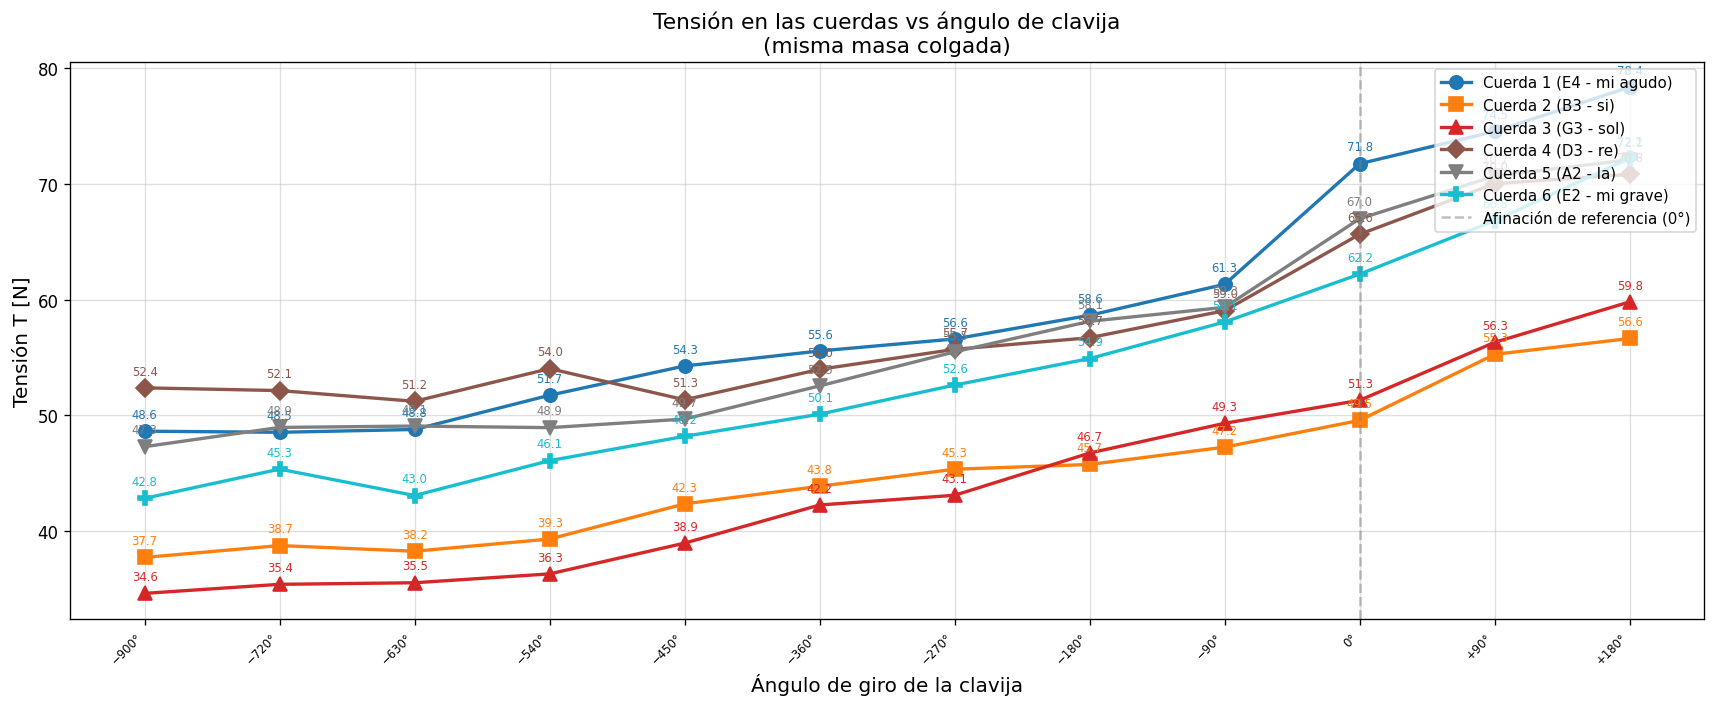

✅ Guardada 'tension_vs_angulo.png'


In [7]:
# ============================================================
# GRÁFICA 1: T vs ángulo de clavija (una línea por cuerda)
# ============================================================

n_cuerdas_plot = df_res['cuerda'].nunique()
fig_w = max(10, 1.2 * len(orden_ang))
fig, ax = plt.subplots(figsize=(fig_w, 6))

colores   = plt.cm.tab10(np.linspace(0, 0.9, n_cuerdas_plot))
marcadores = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<']
x_pos = np.arange(len(orden_ang))

for idx, c in enumerate(sorted(df_res['cuerda'].unique())):
    sub = df_res[df_res['cuerda'] == c].sort_values('angulo')
    if sub.empty:
        continue
    T_vals = sub['T_N'].values
    mk = marcadores[idx % len(marcadores)]
    ax.plot(x_pos, T_vals,
            color=colores[idx], marker=mk,
            linewidth=2, markersize=8, label=NOMBRES_CUERDAS.get(c, f'Cuerda {c}'))
    for xi, Ti in zip(x_pos, T_vals):
        ax.annotate(f'{Ti:.1f}', (xi, Ti),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=7, color=colores[idx])

ax.set_xticks(x_pos)
ax.set_xticklabels(orden_ang, fontsize=max(7, 11 - len(orden_ang)//3), rotation=45, ha='right')
ax.set_xlabel('Ángulo de giro de la clavija', fontsize=12)
ax.set_ylabel('Tensión T [N]', fontsize=12)
ax.set_title('Tensión en las cuerdas vs ángulo de clavija\n(misma masa colgada)', fontsize=13)

# Línea vertical en 0°
idx_0 = orden_ang.index('0°') if '0°' in orden_ang else None
if idx_0 is not None:
    ax.axvline(x=idx_0, color='gray', linestyle='--', alpha=0.5, label='Afinación de referencia (0°)')

ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('tension_vs_angulo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'tension_vs_angulo.png'")


---
## Celda 8 – Gráfica 2: Barras agrupadas de tensión

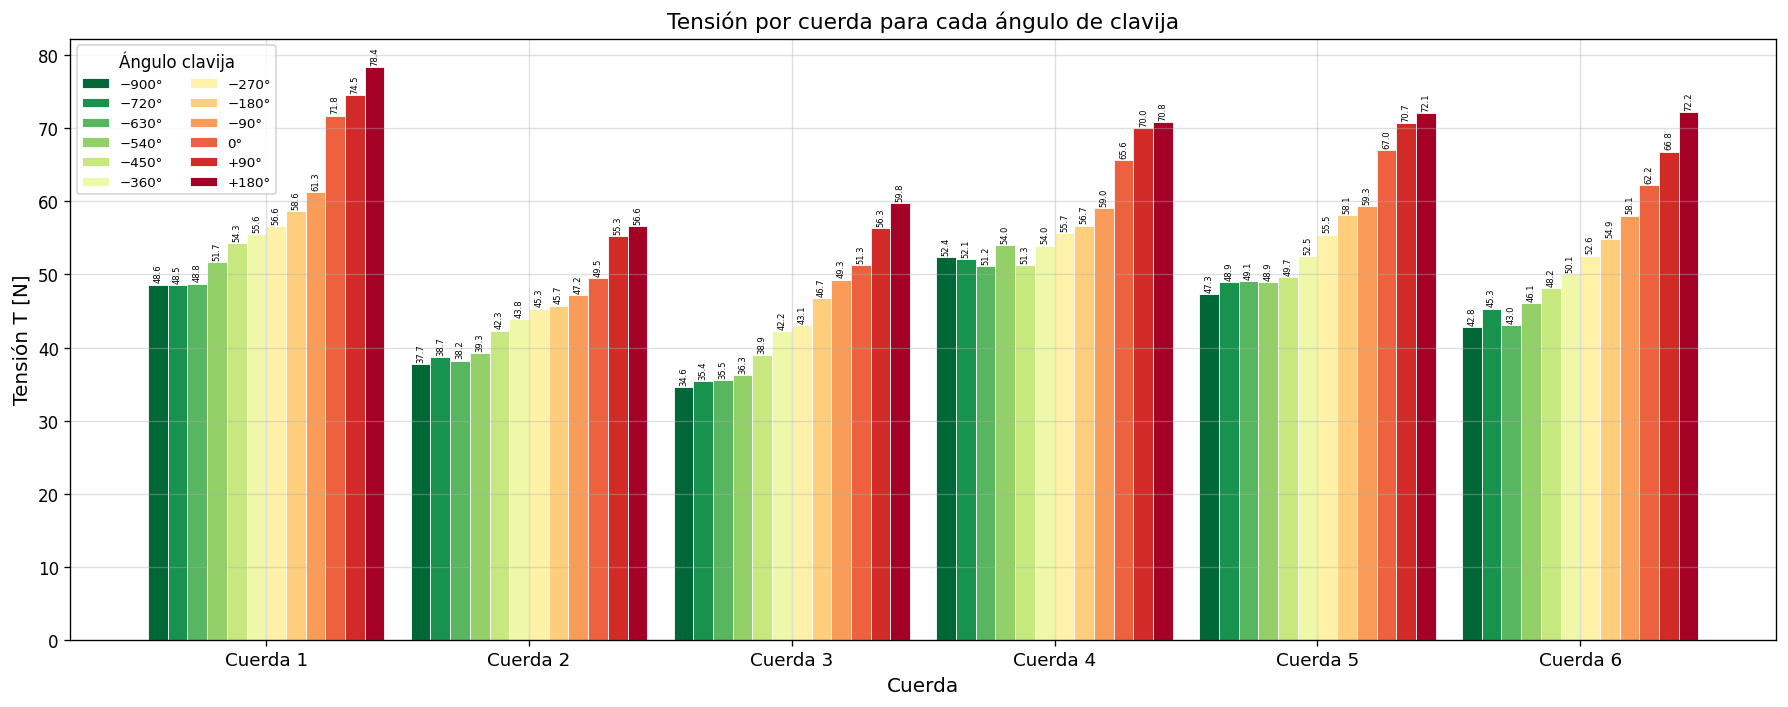

✅ Guardada 'barras_tension.png'


In [8]:
# ============================================================
# GRÁFICA 2: Barras agrupadas por cuerda
# Paleta dinámica según número de ángulos
# ============================================================

n_cuerdas = len(df_raw)
n_angulos = len(orden_ang)
bar_width = max(0.05, min(0.15, 0.9 / n_angulos))
x_base    = np.arange(n_cuerdas)

# Paleta dinámica
cmap_barras = plt.cm.RdYlGn_r
paleta = [cmap_barras(i / max(n_angulos - 1, 1)) for i in range(n_angulos)]

fig_w = max(13, 1.5 * n_cuerdas + 0.5 * n_angulos)
fig, ax = plt.subplots(figsize=(fig_w, 6))

for i, ang in enumerate(orden_ang):
    offset = (i - n_angulos / 2 + 0.5) * bar_width
    vals = tabla_T[ang].values
    bars = ax.bar(x_base + offset, vals, width=bar_width,
                  label=ang, color=paleta[i], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom',
                fontsize=max(5, 8 - n_angulos//4), rotation=90)

ax.set_xticks(x_base)
ax.set_xticklabels([f'Cuerda {i+1}' for i in range(n_cuerdas)], fontsize=11)
ax.set_xlabel('Cuerda', fontsize=12)
ax.set_ylabel('Tensión T [N]', fontsize=12)
ax.set_title('Tensión por cuerda para cada ángulo de clavija', fontsize=13)
ax.legend(title='Ángulo clavija', fontsize=8, ncol=max(1, n_angulos//5))
plt.tight_layout()
plt.savefig('barras_tension.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'barras_tension.png'")


---
## Celda 9 – Gráfica 3: Panel individual por cuerda (T vs y)

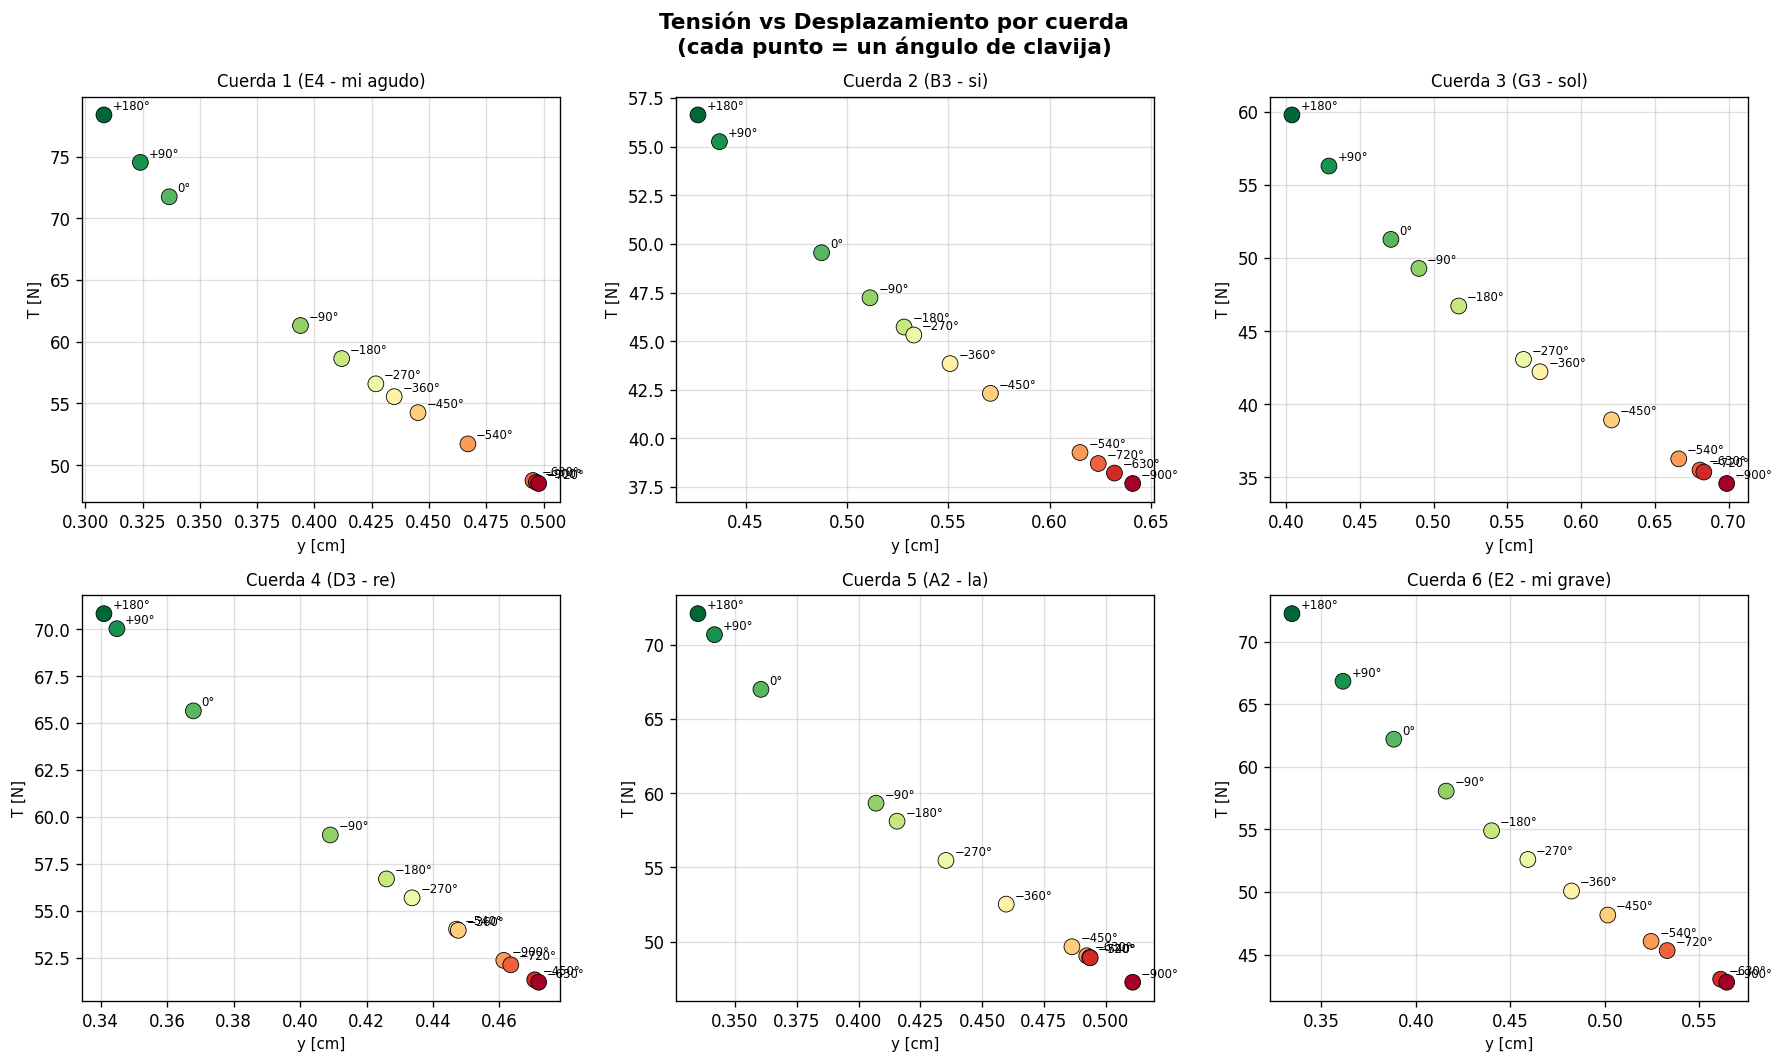

✅ Guardada 'panel_T_vs_y.png'


In [9]:
# ============================================================
# GRÁFICA 3: Panel — T vs y para cada cuerda
# ============================================================

n_cuerdas_plot = df_res['cuerda'].nunique()
cuerdas_unicas = sorted(df_res['cuerda'].unique())

# Layout dinámico de filas/columnas
n_cols = min(3, n_cuerdas_plot)
n_rows = int(np.ceil(n_cuerdas_plot / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
fig.suptitle('Tensión vs Desplazamiento por cuerda\n(cada punto = un ángulo de clavija)',
             fontsize=13, fontweight='bold')

# Asegurar que axes sea siempre 2D
if n_cuerdas_plot == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, c in enumerate(cuerdas_unicas):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    sub = df_res[df_res['cuerda'] == c].sort_values('y_cm')

    sc = ax.scatter(sub['y_cm'], sub['T_N'],
                    c=range(len(sub)), cmap='RdYlGn_r',
                    s=90, edgecolors='black', linewidths=0.5, zorder=5)

    for _, row_data in sub.iterrows():
        ax.annotate(row_data['angulo'], (row_data['y_cm'], row_data['T_N']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

    ax.set_title(NOMBRES_CUERDAS.get(c, f'Cuerda {c}'), fontsize=10)
    ax.set_xlabel('y [cm]', fontsize=9)
    ax.set_ylabel('T [N]', fontsize=9)

# Ocultar ejes vacíos si el grid es mayor que las cuerdas
for idx in range(n_cuerdas_plot, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('panel_T_vs_y.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'panel_T_vs_y.png'")


---
## Celda 10 – Variación relativa de tensión respecto a la afinación (0°)

Variación porcentual de T respecto a la afinación de referencia (0°):
angulo    −900°  −720°  −630°  −540°  −450°  −360°  −270°  −180°   −90°   0°   +90°  +180°
Cuerda 1 -32.26 -32.39 -32.05 -27.92 -24.39 -22.58 -21.13 -18.28 -14.55  0.0   3.89   9.25
Cuerda 2 -23.94 -21.87 -22.86 -20.73 -14.59 -11.51  -8.53  -7.70  -4.67  0.0  11.53  14.30
Cuerda 3 -32.58 -31.05 -30.79 -29.29 -24.10 -17.67 -16.02  -8.90  -3.88  0.0   9.79  16.61
Cuerda 4 -20.24 -20.61 -22.02 -17.71 -21.82 -17.80 -15.17 -13.64 -10.07  0.0   6.67   7.89
Cuerda 5 -29.45 -26.96 -26.78 -26.99 -25.88 -21.59 -17.20 -13.26 -11.45  0.0   5.50   7.61
Cuerda 6 -31.20 -27.13 -30.80 -25.95 -22.57 -19.49 -15.44 -11.75  -6.66  0.0   7.44  16.12

Interpretación: positivo → más tensión que afinada | negativo → menos tensión


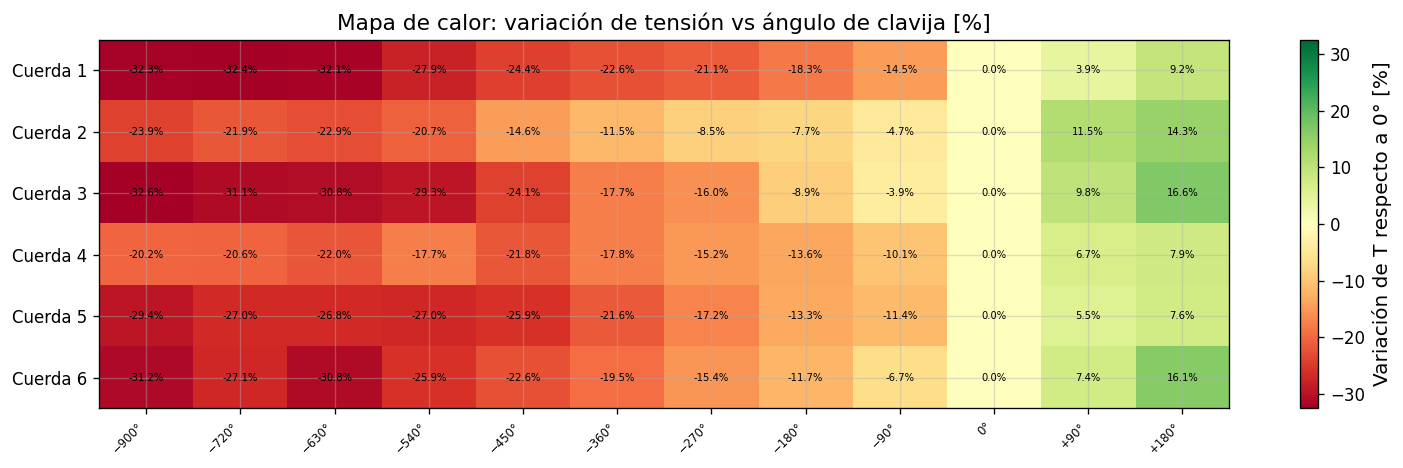

✅ Guardada 'heatmap_variacion.png'


In [10]:
# ============================================================
# VARIACIÓN PORCENTUAL RESPECTO A T(0°)
# ============================================================

T_ref = tabla_T['0°'].values  # T en estado afinado para cada cuerda

tabla_var = tabla_T.copy()
for ang in orden_ang:
    tabla_var[ang] = ((tabla_T[ang].values - T_ref) / T_ref) * 100

print('Variación porcentual de T respecto a la afinación de referencia (0°):')
print(tabla_var.round(2).to_string())
print()
print('Interpretación: positivo → más tensión que afinada | negativo → menos tensión')

# Gráfica de calor (heatmap)
fig_w = max(8, 0.9 * len(orden_ang) + 2)
fig, ax = plt.subplots(figsize=(fig_w, 4))
data_hm = tabla_var.values.astype(float)
vmax = np.abs(data_hm).max()
im = ax.imshow(data_hm, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Variación de T respecto a 0° [%]')

ax.set_xticks(range(len(orden_ang)))
ax.set_xticklabels(orden_ang, rotation=45, ha='right',
                   fontsize=max(7, 10 - len(orden_ang)//3))
ax.set_yticks(range(len(tabla_var)))
ax.set_yticklabels(tabla_var.index)
ax.set_title('Mapa de calor: variación de tensión vs ángulo de clavija [%]')

# Anotar valores
for i in range(data_hm.shape[0]):
    for j in range(data_hm.shape[1]):
        ax.text(j, i, f'{data_hm[i,j]:.1f}%',
                ha='center', va='center',
                fontsize=max(6, 9 - len(orden_ang)//4), color='black')

plt.tight_layout()
plt.savefig('heatmap_variacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'heatmap_variacion.png'")


---
## Celda 11 – Exportar resultados a CSV

In [11]:
# ============================================================
# EXPORTAR TABLA COMPLETA DE RESULTADOS
# ============================================================

df_export = df_res[['cuerda','angulo','masa_kg','y_cm','theta_deg','T_N','deltaL_mm']].copy()
df_export.columns = ['cuerda','angulo_clavija','masa_kg','y_cm','theta_grados','T_N','deltaL_mm']
df_export.to_csv('resultados_cuerdas.csv', index=False, float_format='%.6f')

print('✅ Resultados detallados guardados en resultados_cuerdas.csv')
print()

# Tabla pivote de tensiones
tabla_T.round(4).to_csv('tabla_tensiones.csv')
print('✅ Tabla de tensiones guardada en tabla_tensiones.csv')
print()
print('Vista previa de la tabla de tensiones [N]:')
print(tabla_T.round(2).to_string())

✅ Resultados detallados guardados en resultados_cuerdas.csv

✅ Tabla de tensiones guardada en tabla_tensiones.csv

Vista previa de la tabla de tensiones [N]:
angulo    −900°  −720°  −630°  −540°  −450°  −360°  −270°  −180°   −90°     0°   +90°  +180°
Cuerda 1  48.61  48.51  48.76  51.72  54.25  55.55  56.59  58.64  61.32  71.75  74.54  78.39
Cuerda 2  37.68  38.71  38.22  39.28  42.32  43.85  45.32  45.73  47.23  49.55  55.26  56.63
Cuerda 3  34.57  35.36  35.49  36.26  38.92  42.22  43.06  46.72  49.29  51.28  56.30  59.80
Cuerda 4  52.36  52.12  51.19  54.02  51.32  53.96  55.69  56.70  59.04  65.65  70.03  70.83
Cuerda 5  47.27  48.93  49.05  48.91  49.66  52.53  55.47  58.12  59.33  67.00  70.68  72.10
Cuerda 6  42.80  45.33  43.04  46.06  48.16  50.08  52.60  54.89  58.06  62.20  66.83  72.23


---
## Celda 12 – Conclusiones

### Interpretación física

1. **Tensionar (+90°, +180°):** Al girar la clavija en sentido de tensionado, la cuerda se acorta en el clavijero, aumentando la tensión. Esto se refleja en un **menor desplazamiento `y`** al colgar la misma masa, y por tanto una **mayor T calculada**.

2. **Destensionar (−90°, −180°):** El giro inverso aumenta la longitud libre de la cuerda, reduciéndose la tensión. Se obtiene **mayor `y`** y **menor T**.

3. **Comparación entre cuerdas:** Las cuerdas graves (5, 6) tienen mayor masa lineal y distintas propiedades elásticas, por lo que su tensión a la misma afinación difiere de las cuerdas agudas.

### Posibles fuentes de error
- El giro de la clavija no es perfectamente reproducible (tolerancia del ángulo real).
- Rozamiento en la cejuela o el puente que redistribuye la tensión de forma no uniforme a lo largo de la cuerda.
- La hipótesis `L = constante` asume que la longitud vibrante no cambia al girar la clavija, lo cual es válido si la cuerda no se desplaza lateralmente en la cejuela.